<a href="https://colab.research.google.com/github/Bachbean/Predicting-the-Unpredictable/blob/main/scripts/L63_lyapunov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of original data points: 10000

Points available for Lyapunov analysis: 9818
Valid nearest-neighbor pairs: 9818

LYAPUNOV ANALYSIS
tau = 16
m = 3
Theiler window = 16 samples
Fit region = 5 to 54 samples

Estimated largest Lyapunov exponent:
lambda_max = 0.01500121
Units: per sample
R^2 of linear fit = 0.996962


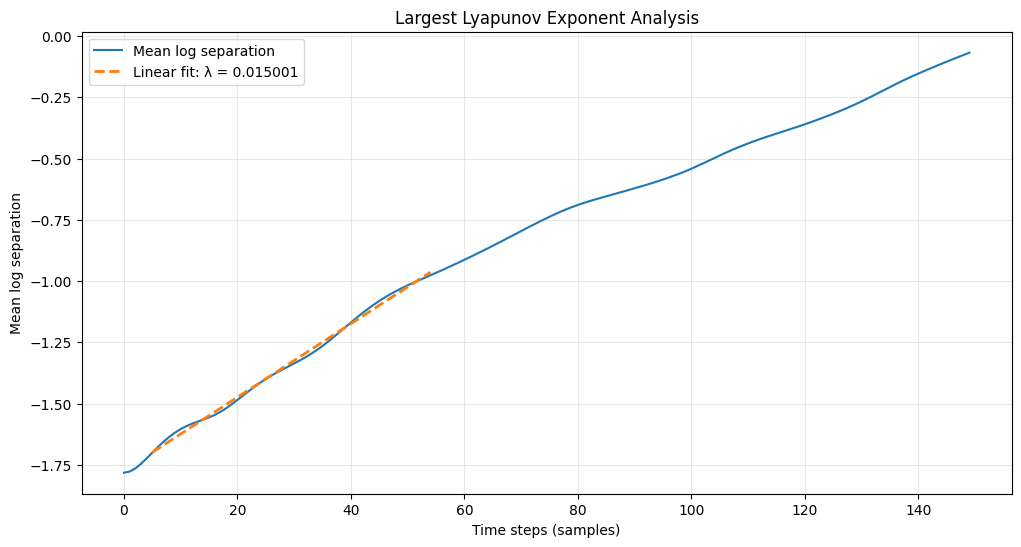

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial import cKDTree


# ============================================================
# 1. LOAD DATA
# ============================================================

file_name = "https://raw.githubusercontent.com/Bachbean/Predicting-the-Unpredictable/refs/heads/main/scripts/L63_x.txt"

data_all = np.loadtxt(file_name, dtype=np.float64)
data = data_all[:10000]
data = np.asarray(data).squeeze()

if data.ndim != 1:
    raise ValueError("Data must be a one-dimensional time series.")

if np.any(~np.isfinite(data)):
    raise ValueError("Data contains NaN or infinite values.")

print("Number of original data points:", len(data))


# ============================================================
# 2. RECONSTRUCTION SETTINGS
# ============================================================

# From your AMI analysis
tau = 16
# From your False Nearest Neighbors analysis
m = 3


# ============================================================
# 3. CREATE DELAY EMBEDDING
# ============================================================

def delay_embed(data, m, tau):

    N = len(data) - (m - 1) * tau

    X = np.empty((N, m))

    for j in range(m):
        X[:, j] = data[
            j * tau : j * tau + N
        ]

    return X


X = delay_embed(data, m, tau)
# ============================================================
# 5. LYAPUNOV ANALYSIS SETTINGS
# ============================================================

# Exclude nearby points in TIME from being selected
# as nearest neighbors.
#
# tau is a reasonable starting choice, but this should
# later be tested for robustness.
theiler_window = tau


# Number of future steps over which we follow divergence
max_k = 150


# Region of the divergence curve that will initially
# be fitted with a straight line.
#
# IMPORTANT:
# These are only starting values.
# After seeing the graph, choose the EARLY region
# that actually looks approximately linear.
fit_start = 5
fit_end = 55


# Time between consecutive measurements.
#
# If you do not know the physical sampling interval,
# leave this at 1.0. The resulting Lyapunov exponent
# will then be "per sample".
dt = 1.0


# ============================================================
# 6. PREPARE POINTS FOR LYAPUNOV ANALYSIS
# ============================================================

# We need enough future points to follow each pair
# for max_k steps.

usable_points = len(X) - max_k

if usable_points <= 0:
    raise ValueError("max_k is too large for the data set.")

X_search = X[:usable_points]

print("\nPoints available for Lyapunov analysis:",
      usable_points)


# ============================================================
# 7. FIND NEAREST NEIGHBOR OF EACH STATE
# ============================================================

# Build an efficient nearest-neighbor search tree
tree = cKDTree(X_search)


# We request enough nearby candidates so that after
# excluding the Theiler window, we should still have
# a valid spatial neighbor.

number_candidates = min(
    2 * theiler_window + 20,
    usable_points
)

distances, indices = tree.query(
    X_search,
    k=number_candidates
)


nearest_neighbor = np.full(
    usable_points,
    -1,
    dtype=int
)


for i in range(usable_points):

    for distance, candidate in zip(
        distances[i],
        indices[i]
    ):

        # Candidate must actually exist
        if candidate >= usable_points:
            continue

        # Reject temporally nearby points
        if abs(candidate - i) <= theiler_window:
            continue

        # Reject identical points
        if not np.isfinite(distance) or distance <= 0:
            continue

        nearest_neighbor[i] = candidate
        break


# Keep only points for which a valid neighbor was found

reference_indices = np.where(
    nearest_neighbor >= 0
)[0]

neighbor_indices = nearest_neighbor[
    reference_indices
]


print(
    "Valid nearest-neighbor pairs:",
    len(reference_indices)
)


if len(reference_indices) == 0:
    raise ValueError(
        "No valid nearest-neighbor pairs found."
    )


# ============================================================
# 8. FOLLOW HOW THE NEIGHBORS DIVERGE
# ============================================================

mean_log_divergence = np.full(
    max_k,
    np.nan
)

number_of_pairs = np.zeros(
    max_k,
    dtype=int
)


for k in range(max_k):

    # Position of trajectory 1 after k steps
    A = X[reference_indices + k]

    # Position of trajectory 2 after k steps
    B = X[neighbor_indices + k]

    # Euclidean separation in reconstructed state space
    separation = np.linalg.norm(
        A - B,
        axis=1
    )

    # Remove zero / invalid distances
    valid = (
        np.isfinite(separation)
        & (separation > 0)
    )

    separation = separation[valid]

    number_of_pairs[k] = len(separation)

    if len(separation) > 0:

        # Rosenstein method:
        # average logarithm of trajectory separation
        mean_log_divergence[k] = np.mean(
            np.log(separation)
        )


# ============================================================
# 9. FIT LINEAR REGION
# ============================================================

k_values = np.arange(max_k)

fit_mask = (
    (k_values >= fit_start)
    & (k_values < fit_end)
    & np.isfinite(mean_log_divergence)
)


x_fit = k_values[fit_mask] * dt
y_fit = mean_log_divergence[fit_mask]


if len(x_fit) < 3:
    raise ValueError(
        "Not enough valid values in the chosen fit range."
    )


# Linear regression
slope, intercept = np.polyfit(
    x_fit,
    y_fit,
    1
)


# Predicted values
y_pred = slope * x_fit + intercept


# Calculate R^2
ss_res = np.sum(
    (y_fit - y_pred) ** 2
)

ss_tot = np.sum(
    (y_fit - np.mean(y_fit)) ** 2
)

if ss_tot > 0:
    r_squared = 1 - ss_res / ss_tot
else:
    r_squared = np.nan


largest_lyapunov = slope


# ============================================================
# 10. PRINT RESULTS
# ============================================================

print("\n==============================")
print("LYAPUNOV ANALYSIS")
print("==============================")

print("tau =", tau)
print("m =", m)

print(
    "Theiler window =",
    theiler_window,
    "samples"
)

print(
    "Fit region =",
    fit_start,
    "to",
    fit_end - 1,
    "samples"
)

print(
    "\nEstimated largest Lyapunov exponent:"
)

print(
    f"lambda_max = {largest_lyapunov:.8f}"
)

if dt == 1.0:
    print("Units: per sample")
else:
    print("Units: per unit time")

print(
    f"R^2 of linear fit = {r_squared:.6f}"
)


# ============================================================
# 11. PLOT LOGARITHMIC DIVERGENCE
# ============================================================

plt.figure(figsize=(12, 6))


# Full divergence curve
plt.plot(
    k_values * dt,
    mean_log_divergence,
    linewidth=1.5,
    label="Mean log separation"
)


# Linear fit
plt.plot(
    x_fit,
    y_pred,
    linestyle="--",
    linewidth=2,
    label=(
        f"Linear fit: λ = "
        f"{largest_lyapunov:.6f}"
    )
)


plt.xlabel(
    "Time" if dt != 1.0
    else "Time steps (samples)"
)

plt.ylabel(
    "Mean log separation"
)

plt.title(
    "Largest Lyapunov Exponent Analysis"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()